Modeling the 2 merged datasets

In [1]:
import pandas as pd
import numpy as np
import glob
import os
from PIL import Image
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Activation, Dense, BatchNormalization, Dropout,
    Conv2D, Conv2DTranspose, MaxPooling2D,
    UpSampling2D, Input, Reshape
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

2026-03-06 11:09:15.369966: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772795355.584353      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772795355.645444      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772795356.128770      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772795356.128811      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772795356.128814      24 computation_placer.cc:177] computation placer alr

## DataSet

In [2]:
#Resized Dataset for Skin Lesion Segment #train data

train_ground_1 = glob.glob('/kaggle/input/datasets/apurboshahidshawon/resized-dataset-for-skin-lesion-segmentation-new/Resized_segmentation_dataset_new/train/ground truth/img/*.jpg')
train_input_1 = glob.glob('/kaggle/input/datasets/apurboshahidshawon/resized-dataset-for-skin-lesion-segmentation-new/Resized_segmentation_dataset_new/train/input/img/*.jpg')

print(f"Resized Dataset -> Images: {len(train_input_1)}, Masks: {len(train_ground_1)}")

Resized Dataset -> Images: 6503, Masks: 6503


In [3]:
#testing data # resized
test_ground_1 = glob.glob(
 '/kaggle/input/datasets/apurboshahidshawon/resized-dataset-for-skin-lesion-segmentation-new/Resized_segmentation_dataset_new/test/ground truth/img/*.jpg'
)

test_input_1 = glob.glob(
 '/kaggle/input/datasets/apurboshahidshawon/resized-dataset-for-skin-lesion-segmentation-new/Resized_segmentation_dataset_new/test/input/img/*.jpg'
)

print(f"Resized Dataset -> Images: {len(test_input_1)}, Masks: {len(test_ground_1)}")

Resized Dataset -> Images: 1626, Masks: 1626


In [4]:
from sklearn.model_selection import train_test_split

resized_train_imgs, resized_val_imgs, \
resized_train_masks, resized_val_masks = train_test_split(
    train_input_1,
    train_ground_1,
    test_size=0.2,
    random_state=42
)

print("Resized after split:")
print("Train:", len(resized_train_imgs))
print("Val  :", len(resized_val_imgs))

Resized after split:
Train: 5202
Val  : 1301


In [5]:
#Skin Cancer HAM10000: Raw and Lesion # all
ham_raw = glob.glob('/kaggle/input/datasets/mfazrinizar/skin-cancer-ham10000-raw-and-lesion-segmentation/data/raw/*.jpg')
ham_masks = glob.glob('/kaggle/input/datasets/mfazrinizar/skin-cancer-ham10000-raw-and-lesion-segmentation/data/segmentation/*.png')


print(f"HAM10000 Dataset -> Images: {len(ham_raw)}, Masks: {len(ham_masks)}")

HAM10000 Dataset -> Images: 10015, Masks: 10015


In [6]:
output_base = "/kaggle/working/"

folders = [
    "train/input", "train/ground truth",
    "val/input",   "val/ground truth",
    "test/input",  "test/ground truth"
]
for folder in folders:
    os.makedirs(os.path.join(output_base, folder), exist_ok=True)

# ===============================
# VALID IMAGE–MASK PAIRS
# ===============================
valid_images = []

for img_path in ham_raw:
    base_name = os.path.basename(img_path).replace(".jpg", "")
    mask_name = os.path.join(
        '/kaggle/input/datasets/mfazrinizar/skin-cancer-ham10000-raw-and-lesion-segmentation/data/segmentation',
        base_name + "_segmentation.png"
    )
    if os.path.exists(mask_name):
        valid_images.append(base_name)

print("Total valid image-mask pairs:", len(valid_images))

# ===============================
# SPLIT DATA (70% Train, 15% Val, 15% Test)
# ===============================
train_imgs, temp_imgs = train_test_split(valid_images, test_size=0.30, random_state=42)
val_imgs, test_imgs  = train_test_split(temp_imgs, test_size=0.50, random_state=42)

# ===============================
# SYMLINK FUNCTION
# ===============================
def link_data(img_list, split):
    for base_name in img_list:
        img_src  = os.path.join('/kaggle/input/datasets/mfazrinizar/skin-cancer-ham10000-raw-and-lesion-segmentation/data/raw', base_name + ".jpg")
        mask_src = os.path.join('/kaggle/input/datasets/mfazrinizar/skin-cancer-ham10000-raw-and-lesion-segmentation/data/segmentation', base_name + "_segmentation.png")

        img_dst  = os.path.join(output_base, split, "input", base_name + ".jpg")
        mask_dst = os.path.join(output_base, split, "ground truth", base_name + "_segmentation.png")

        if not os.path.exists(img_dst):
            os.symlink(img_src, img_dst)

        if not os.path.exists(mask_dst):
            os.symlink(mask_src, mask_dst)

# ===============================
# EXECUTE SPLITTING
# ===============================
link_data(train_imgs, "train")
link_data(val_imgs, "val")
link_data(test_imgs, "test")

print("✅ Raw + Segmentation dataset split completed successfully!")

Total valid image-mask pairs: 10015
✅ Raw + Segmentation dataset split completed successfully!


In [7]:
print("Resized Dataset:")
print("Train Images:", len(train_input_1))
print("Train Masks :", len(train_ground_1))

print("Test Images :", len(test_input_1))
print("Test Masks  :", len(test_ground_1))

Resized Dataset:
Train Images: 6503
Train Masks : 6503
Test Images : 1626
Test Masks  : 1626


In [8]:
print("HAM10000 Dataset:")
print("Train:", len(train_imgs))
print("Val  :", len(val_imgs))
print("Test :", len(test_imgs))

HAM10000 Dataset:
Train: 7010
Val  : 1502
Test : 1503


## DATA MERGING


In [9]:
# Combine all image paths from both datasets for Training
train_img_paths = train_input_1 + [os.path.join('/kaggle/input/datasets/mfazrinizar/skin-cancer-ham10000-raw-and-lesion-segmentation/data/raw', b + ".jpg") for b in train_imgs]
train_mask_paths = train_ground_1 + [os.path.join('/kaggle/input/datasets/mfazrinizar/skin-cancer-ham10000-raw-and-lesion-segmentation/data/segmentation', b + "_segmentation.png") for b in train_imgs]

# Combine all image paths for Validation
val_img_paths = resized_val_imgs + [os.path.join('/kaggle/input/datasets/mfazrinizar/skin-cancer-ham10000-raw-and-lesion-segmentation/data/raw', b + ".jpg") for b in val_imgs]
val_mask_paths = resized_val_masks + [os.path.join('/kaggle/input/datasets/mfazrinizar/skin-cancer-ham10000-raw-and-lesion-segmentation/data/segmentation', b + "_segmentation.png") for b in val_imgs]

# Combine all image paths for Testing
test_img_paths = test_input_1 + [os.path.join('/kaggle/input/datasets/mfazrinizar/skin-cancer-ham10000-raw-and-lesion-segmentation/data/raw', b + ".jpg") for b in test_imgs]
test_mask_paths = test_ground_1 + [os.path.join('/kaggle/input/datasets/mfazrinizar/skin-cancer-ham10000-raw-and-lesion-segmentation/data/segmentation', b + "_segmentation.png") for b in test_imgs]

In [10]:
print(f"Test Dataset -> Images: {len(test_img_paths)}, Masks: {len(test_mask_paths)}")

Test Dataset -> Images: 3129, Masks: 3129


In [11]:
print(f"Train Dataset -> Images: {len(train_img_paths )}, Masks: {len(train_mask_paths)}")

Train Dataset -> Images: 13513, Masks: 13513


In [12]:
print(f"Val Dataset -> Images: {len(val_img_paths)}, Masks: {len(val_mask_paths)}")

Val Dataset -> Images: 2803, Masks: 2803


In [13]:
print(f"Sorted Train Images: {len(train_img_paths)}, Sorted Train Masks: {len(train_mask_paths)}")

Sorted Train Images: 13513, Sorted Train Masks: 13513


## IMAGE & MASK PREPROCESSING

In [14]:
# --- STEP 2: IMAGE & MASK PREPROCESSING ---
import tensorflow as tf
IMG_SIZE = (128, 128)

def load_and_preprocess(img_path, mask_path):
    # Load and process Image
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    
    # Load and process Mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_image(mask, channels=3, expand_animations=False)
    mask = tf.image.resize(mask, IMG_SIZE)
    mask = tf.cast(mask, tf.float32) / 255.0
    mask = tf.where(mask > 0.5, 1.0, 0.0) # Ensure it is a binary mask
    
    return img, mask

## DATA AUGMENTATION

In [15]:
def apply_augmentation(img, mask):
    # Randomly flip horizontally and vertically
    img = tf.image.random_flip_left_right(img)
    mask = tf.image.random_flip_left_right(mask)
    
    img = tf.image.random_flip_up_down(img)
    mask = tf.image.random_flip_up_down(mask)
    
    # Random brightness (only for the image)
    img = tf.image.random_brightness(img, max_delta=0.1)
    
    return img, mask

## Train, Val and Test data

In [16]:
# --- HIGH-SPEED TRAINING PIPELINE ---
BATCH_SIZE = 32

# 1. Create dataset from merged paths
train_ds = tf.data.Dataset.from_tensor_slices((train_img_paths, train_mask_paths))

# 2. SHUFFLE: Mix the image-mask pairs (Fastest when done on paths)
train_ds = train_ds.shuffle(buffer_size=len(train_img_paths))

# 3. PREPROCESS: Load and resize images in parallel
train_ds = train_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

# 4. AUGMENT: Apply random transformations
train_ds = train_ds.map(apply_augmentation, num_parallel_calls=tf.data.AUTOTUNE)

# 5. BATCH & PREFETCH: Group data and prepare next batch ahead of time
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Training Pipeline is ready with Shuffling and Augmentation!")

I0000 00:00:1772795414.754717      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772795414.761277      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Training Pipeline is ready with Shuffling and Augmentation!


In [17]:
# --- STEP 3: HIGH-SPEED DATA PIPELINE ---

# Create Validation Dataset
val_ds = tf.data.Dataset.from_tensor_slices((val_img_paths, val_mask_paths))
val_ds = val_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [18]:
# Create Testing Dataset
test_ds = tf.data.Dataset.from_tensor_slices((test_img_paths, test_mask_paths))
test_ds = test_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [19]:
test_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None))>

## VISUALIZATION CODE

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0012217388..0.82401574].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.16957945..1.0323246].


(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)


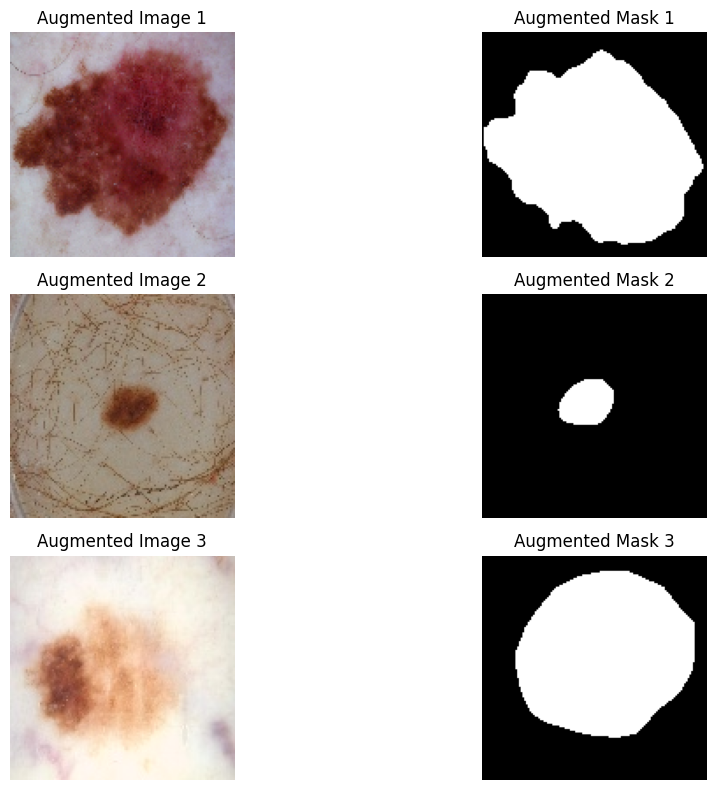

In [20]:
import matplotlib.pyplot as plt

# --- VISUALIZATION CODE ---
# Take 1 batch from the training dataset
for images, masks in train_ds.take(1):
    plt.figure(figsize=(12, 8))
    
    # Plot 3 samples from the batch
    for i in range(3):
        # Plot Original Image (Augmented)
        plt.subplot(3, 2, 2*i + 1)
        plt.imshow(images[i])
        print(images[i].shape)
        plt.title(f"Augmented Image {i+1}")
        plt.axis("off")
        
        # Plot Corresponding Mask (Augmented)
        plt.subplot(3, 2, 2*i + 2)
        plt.imshow(masks[i].numpy().squeeze(), cmap="gray")
        print(masks[i].shape)
        plt.title(f"Augmented Mask {i+1}")
        plt.axis("off")
        
    plt.tight_layout()
  # Use tf.clip_by_value to keep pixels between 0 and 1
    plt.show()

## Model 

* The architecture we are implementing is suggested in [this](https://arxiv.org/pdf/1511.00561.pdf) paper.

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

segnet = Sequential([

     # Encoding layer
     Input(shape= (128, 128, 3)),
     Conv2D(64, (3, 3), padding='same', activation= 'relu', strides= (1,1)),
     BatchNormalization(),
     Conv2D(64, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     MaxPooling2D(),

     Conv2D(128, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(name='bn3'),
     Conv2D(128, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     MaxPooling2D(),

     Conv2D(256, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2D(256, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2D(256, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     MaxPooling2D(),

     Conv2D(512, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2D(512, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2D(512, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     MaxPooling2D(),
     Conv2D(512, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2D(512, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2D(512, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     MaxPooling2D(),
     Dense(1024, activation = 'relu'),
     Dense(1024, activation = 'relu'),

     # Decoding Layer
     UpSampling2D(),
     Conv2DTranspose(512, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2DTranspose(512, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2DTranspose(512, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),

     UpSampling2D(),
     Conv2DTranspose(512, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2DTranspose(512, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2DTranspose(256, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),

     UpSampling2D(),
     Conv2DTranspose(256, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2DTranspose(256, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2DTranspose(128, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),

     UpSampling2D(),
     Conv2DTranspose(128, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2DTranspose(64, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),

     UpSampling2D(),
     Conv2DTranspose(64, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Activation('relu'),
     Conv2DTranspose(3, (3, 3), padding='same', activation= 'sigmoid'),
     BatchNormalization(),
])


In [22]:
segnet.compile(optimizer= Adam(learning_rate=0.001),
               loss= ["binary_crossentropy"], metrics=['accuracy'])
segnet.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 64, 64, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 512)    │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 33,394,831 (127.39 MB)

 Trainable params: 33,378,953 (127.33 MB)

 Non-trainable params: 15,878 (62.02 KB)

## Callbacks and Early stopping

**callbacks saves the best version of your model automatically based on the highest validation accuracy.**

In [23]:
# --- STEP 2: DEFINING CALLBACKS ---
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 1. Checkpoint: Saves the best model weights based on validation performance
checkpoint = ModelCheckpoint(
    "best_segnet_model.keras",
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max'
)

# 2. Early Stopping: Stops training if the model stops improving to save time
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15, 
    restore_best_weights=True, 
    verbose=1
)

# 3. Reduce LR: Lowers learning rate when learning plateaus to find the global minimum
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    patience=5,
    factor=0.2,
    min_lr=1e-6,
    verbose=1
)

# Combine all into one list
callbacks_list = [early_stopping, reduce_lr, checkpoint]

## Model Training 

In [24]:
segnet.fit(train_ds, epochs= 10, batch_size= 32, validation_data= val_ds, verbose=1, callbacks= callbacks_list)

Epoch 1/10


I0000 00:00:1772795432.823865      66 service.cc:152] XLA service 0x7ab8a8013700 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772795432.823902      66 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772795432.823906      66 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772795435.843159      66 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-06 11:10:47.517485: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 11:10:47.713601: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 11:10:48.681126: E external/local_xl

422/423 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.2536 - loss: 1.2433

2026-03-06 11:14:18.521902: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 11:14:18.712275: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 11:14:19.088003: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 11:14:19.253237: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 11:14:20.312843: E external/local_xla/xla/stream_

423/423 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.2536 - loss: 1.2422

2026-03-06 11:15:07.733888: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 11:15:07.935409: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 11:15:08.841773: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 11:15:09.016631: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 11:15:10.482881: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.20865, saving model to best_segnet_model.keras
423/423 ━━━━━━━━━━━━━━━━━━━━ 296s 571ms/step - accuracy: 0.2537 - loss: 1.2411 - val_accuracy: 0.2086 - val_loss: 0.5834 - learning_rate: 0.0010
Epoch 2/10
423/423 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.3143 - loss: 0.4847
Epoch 2: val_accuracy improved from 0.20865 to 0.39837, saving model to best_segnet_model.keras
423/423 ━━━━━━━━━━━━━━━━━━━━ 192s 454ms/step - accuracy: 0.3143 - loss: 0.4846 - val_accuracy: 0.3984 - val_loss: 0.3950 - learning_rate: 0.0010
Epoch 3/10
423/423 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.2891 - loss: 0.4141
Epoch 3: val_accuracy did not improve from 0.39837
423/423 ━━━━━━━━━━━━━━━━━━━━ 191s 450ms/step - accuracy: 0.2890 - loss: 0.4142 - val_accuracy: 0.0141 - val_loss: 0.6128 - learning_rate: 0.0010
Epoch 4/10
423/423 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.3351 - loss: 0.4542
Epoch 4: val_accuracy did not improve from 0.39837
423/423 ━

## Model Validation

In [ ]:
# --- EVALUATION ON TEST SET ---
segnet.evaluate(test_ds)

## Save the model

In [ ]:
# Save the entire model to a single file
segnet.save("my_segmentation_model.keras")